**OceanShield AI
Real-Time Detection of Suspicious Maritime Activity using AIS Data**

**Install Libraries**

In [71]:
!pip install pandas numpy
!pip install scikit-learn
!pip install pyspark
!pip install geopy
!pip install folium
!pip install matplotlib seaborn

**Import Libraries**

In [72]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
from pyspark.sql import SparkSession
from geopy.distance import geodesic
import folium
import time

**Load and Explore the Dataset**

In [73]:
import pandas as pd

file_path = "/content/processed_AIS_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1098966, 28)


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,...,dest_lat,dest_lon,dist_km,SOG_kmh,ETA_min,VesselType_enc,Status_enc,Cargo_enc,ETA_hours,Speed_Category
0,367702220,2022-03-31 00:00:01,29.78763,-95.08070,0.1,226.5,340.0,JOE B WARD,NaN,WDI4808,...,29.480858,-92.212083,279.336377,0.1852,4320.000000,12,4,44,72.000000,Stopped
1,671226100,2022-03-31 00:00:01,25.77626,-80.20320,3.2,143.7,511.0,RELIANCE II,IMO9221322,5VHS7,...,27.542911,-80.705088,202.674196,5.9264,2051.912084,46,0,58,34.198535,Slow
2,367767250,2022-03-31 00:00:01,29.31623,-94.78829,4.5,228.1,511.0,GLEN K,NaN,WDJ3358,...,29.480858,-92.212083,250.237720,8.3340,1801.567458,26,0,39,30.026124,Slow
3,338327436,2022-03-31 00:00:03,47.29634,-122.42233,0.0,360.0,511.0,COOL KAT,IMO0000000,NaN,...,47.831804,-122.946382,71.352057,1.0000,4281.123426,17,0,39,71.352057,Stopped
4,367452810,2022-03-31 00:00:06,29.32824,-94.77391,2.6,319.2,511.0,JOHN W JOHNSON,IMO9602344,WDF4516,...,29.480858,-92.212083,248.739208,4.8152,3099.425255,33,0,48,51.657088,Slow


In [74]:
print("Columns:", df.columns.tolist())
df.info()
df.isnull().sum()

Columns: ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'TransceiverClass', 'dest_cluster', 'dest_lat', 'dest_lon', 'dist_km', 'SOG_kmh', 'ETA_min', 'VesselType_enc', 'Status_enc', 'Cargo_enc', 'ETA_hours', 'Speed_Category']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1098966 entries, 0 to 1098965
Data columns (total 28 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   MMSI              1098966 non-null  int64  
 1   BaseDateTime      1098966 non-null  object 
 2   LAT               1098966 non-null  float64
 3   LON               1098966 non-null  float64
 4   SOG               1098966 non-null  float64
 5   COG               1098966 non-null  float64
 6   Heading           1098966 non-null  float64
 7   VesselName        1096501 non-null  object 
 8   IMO               596520 non-null   object 
 9   CallSig

,0
MMSI,0
BaseDateTime,0
LAT,0
LON,0
SOG,0
COG,0
Heading,0
VesselName,2465
IMO,502446
CallSign,122343


In [75]:
df = df.rename(columns={
    'latitude': 'LAT',
    'longitude': 'LON',
    'sog': 'SOG',
    'cog': 'COG',
    'timestamp': 'BaseDateTime',
    'mmsi': 'MMSI'
})

df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'], errors='coerce')

df = df.dropna(subset=['LAT', 'LON', 'BaseDateTime', 'MMSI'])

df.head()

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,...,dest_lat,dest_lon,dist_km,SOG_kmh,ETA_min,VesselType_enc,Status_enc,Cargo_enc,ETA_hours,Speed_Category
0,367702220,2022-03-31 00:00:01,29.78763,-95.08070,0.1,226.5,340.0,JOE B WARD,NaN,WDI4808,...,29.480858,-92.212083,279.336377,0.1852,4320.000000,12,4,44,72.000000,Stopped
1,671226100,2022-03-31 00:00:01,25.77626,-80.20320,3.2,143.7,511.0,RELIANCE II,IMO9221322,5VHS7,...,27.542911,-80.705088,202.674196,5.9264,2051.912084,46,0,58,34.198535,Slow
2,367767250,2022-03-31 00:00:01,29.31623,-94.78829,4.5,228.1,511.0,GLEN K,NaN,WDJ3358,...,29.480858,-92.212083,250.237720,8.3340,1801.567458,26,0,39,30.026124,Slow
3,338327436,2022-03-31 00:00:03,47.29634,-122.42233,0.0,360.0,511.0,COOL KAT,IMO0000000,NaN,...,47.831804,-122.946382,71.352057,1.0000,4281.123426,17,0,39,71.352057,Stopped
4,367452810,2022-03-31 00:00:06,29.32824,-94.77391,2.6,319.2,511.0,JOHN W JOHNSON,IMO9602344,WDF4516,...,29.480858,-92.212083,248.739208,4.8152,3099.425255,33,0,48,51.657088,Slow


In [76]:
df = df.sample(frac=0.3, random_state=42)

**DATA PREPROCESSING**

**Sort Data by Vessel and Time**

In [77]:
df = df.sort_values(by=['MMSI', 'BaseDateTime'])
df = df.reset_index(drop=True)

df.head()

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,...,dest_lat,dest_lon,dist_km,SOG_kmh,ETA_min,VesselType_enc,Status_enc,Cargo_enc,ETA_hours,Speed_Category
0,0,2022-03-31 00:02:27,28.41269,-80.60896,0.4,0.0,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.174546,0.7408,4320.000000,29,10,0,72.000000,Stopped
1,0,2022-03-31 00:03:37,28.41276,-80.60888,0.5,0.0,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.183056,0.9260,4320.000000,29,10,0,72.000000,Stopped
2,0,2022-03-31 00:11:43,28.41218,-80.60824,3.3,277.0,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.125005,6.1116,953.514678,29,10,0,15.891911,Slow
3,0,2022-03-31 00:14:03,28.41302,-80.60821,2.4,139.9,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.218245,4.4448,1312.341320,29,10,0,21.872355,Slow
4,0,2022-03-31 00:15:25,28.41265,-80.60824,0.6,328.2,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.177014,1.1112,4320.000000,29,10,0,72.000000,Stopped


**Handle Missing Values**

In [78]:
print(df.isnull().sum())

df['SOG'] = df['SOG'].fillna(0)
df['COG'] = df['COG'].fillna(method='ffill')

df = df.dropna(subset=['LAT', 'LON', 'BaseDateTime'])

MMSI                     0
BaseDateTime             0
LAT                      0
LON                      0
SOG                      0
COG                      0
Heading                  0
VesselName             773
IMO                 150661
CallSign             36627
VesselType               0
Status                   0
Length                   0
Width                    0
Draft                    0
Cargo                    0
TransceiverClass         0
dest_cluster             0
dest_lat                 0
dest_lon                 0
dist_km                  0
SOG_kmh                  0
ETA_min                  0
VesselType_enc           0
Status_enc               0
Cargo_enc                0
ETA_hours                0
Speed_Category           0
dtype: int64


/tmp/ipykernel_8188/3126089370.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['COG'] = df['COG'].fillna(method='ffill')


**Remove Duplicate Records**

In [79]:
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (329686, 28)


**Filter Invalid Values**

In [80]:
df = df[(df['LAT'] >= -90) & (df['LAT'] <= 90)]
df = df[(df['LON'] >= -180) & (df['LON'] <= 180)]

df = df[df['SOG'] <= 60]

**Ensure Correct Data Types**

In [81]:
df['MMSI'] = df['MMSI'].astype(str)
df['SOG'] = df['SOG'].astype(float)
df['COG'] = df['COG'].astype(float)

**Final Check**

In [82]:
print("Final Dataset Shape:", df.shape)
df.head()

Final Dataset Shape: (328652, 28)


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,...,dest_lat,dest_lon,dist_km,SOG_kmh,ETA_min,VesselType_enc,Status_enc,Cargo_enc,ETA_hours,Speed_Category
0,0,2022-03-31 00:02:27,28.41269,-80.60896,0.4,0.0,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.174546,0.7408,4320.000000,29,10,0,72.000000,Stopped
1,0,2022-03-31 00:03:37,28.41276,-80.60888,0.5,0.0,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.183056,0.9260,4320.000000,29,10,0,72.000000,Stopped
2,0,2022-03-31 00:11:43,28.41218,-80.60824,3.3,277.0,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.125005,6.1116,953.514678,29,10,0,15.891911,Slow
3,0,2022-03-31 00:14:03,28.41302,-80.60821,2.4,139.9,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.218245,4.4448,1312.341320,29,10,0,21.872355,Slow
4,0,2022-03-31 00:15:25,28.41265,-80.60824,0.6,328.2,511.0,CGC SPENCER,NaN,NWHE,...,27.542911,-80.705088,97.177014,1.1112,4320.000000,29,10,0,72.000000,Stopped


**Feature Engineering**

**Speed-Based Features**

In [83]:
df['low_speed'] = df['SOG'] < 2
df['high_speed'] = df['SOG'] > 20

**Course Change (COG Difference)**

In [84]:
df['COG_diff'] = df.groupby('MMSI')['COG'].diff().abs()

df['COG_diff'] = df['COG_diff'].fillna(0)

**Time Gap (AIS Signal Gaps → Dark Activity)**

In [85]:
df['time_diff'] = df.groupby('MMSI')['BaseDateTime'].diff().dt.total_seconds()

df['time_diff'] = df['time_diff'].fillna(0)

df['ais_gap'] = df['time_diff'] > 1800

**Distance Travelled Between Points**

In [86]:
from geopy.distance import geodesic

def calculate_distance(row, prev_row):
    return geodesic((prev_row['LAT'], prev_row['LON']),
                    (row['LAT'], row['LON'])).km

distances = []

for mmsi, group in df.groupby('MMSI'):
    group = group.sort_values('BaseDateTime')
    prev = None

    for _, row in group.iterrows():
        if prev is None:
            distances.append(0)
        else:
            distances.append(calculate_distance(row, prev))
        prev = row

df['distance_km'] = distances

**Loitering Detection (Staying in Same Area)**

In [87]:
df['loitering'] = (df['distance_km'] < 0.5) & (df['time_diff'] > 1800)

**Sudden Speed Change**

In [88]:
df['speed_diff'] = df.groupby('MMSI')['SOG'].diff().abs()
df['speed_diff'] = df['speed_diff'].fillna(0)

**Final Feature Summary**

In [89]:
df[['MMSI','SOG','COG_diff','time_diff','distance_km',
    'loitering','ais_gap','speed_diff']].head()

,MMSI,SOG,COG_diff,time_diff,distance_km,loitering,ais_gap,speed_diff
0,0,0.4,0.0,0.0,0.000000,False,False,0.0
1,0,0.5,0.0,70.0,0.011029,False,False,0.1
2,0,3.3,277.0,486.0,0.089802,False,False,2.8
3,0,2.4,137.1,140.0,0.093140,False,False,0.9
4,0,0.6,188.3,82.0,0.041111,False,False,1.8


**Big Data Pipeline**

Initialize Spark Session

In [90]:
!pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AIS_BigData_Pipeline") \
    .getOrCreate()

print("Spark Session Created")

Spark Session Created


**Load Data into Spark**

In [91]:
spark_df = spark.read.csv("/content/processed_AIS_dataset.csv", header=True, inferSchema=True)

spark_df.printSchema()
spark_df.show(5)

root
 |-- MMSI: integer (nullable = true)
 |-- BaseDateTime: timestamp (nullable = true)
 |-- LAT: double (nullable = true)
 |-- LON: double (nullable = true)
 |-- SOG: double (nullable = true)
 |-- COG: double (nullable = true)
 |-- Heading: double (nullable = true)
 |-- VesselName: string (nullable = true)
 |-- IMO: string (nullable = true)
 |-- CallSign: string (nullable = true)
 |-- VesselType: double (nullable = true)
 |-- Status: double (nullable = true)
 |-- Length: double (nullable = true)
 |-- Width: double (nullable = true)
 |-- Draft: double (nullable = true)
 |-- Cargo: double (nullable = true)
 |-- TransceiverClass: string (nullable = true)
 |-- dest_cluster: integer (nullable = true)
 |-- dest_lat: double (nullable = true)
 |-- dest_lon: double (nullable = true)
 |-- dist_km: double (nullable = true)
 |-- SOG_kmh: double (nullable = true)
 |-- ETA_min: double (nullable = true)
 |-- VesselType_enc: integer (nullable = true)
 |-- Status_enc: integer (nullable = true)
 |-- C

**Basic Distributed Processing**

In [92]:
from pyspark.sql.functions import col

spark_filtered = spark_df.filter(col("SOG") > 0)

spark_grouped = spark_filtered.groupBy("MMSI").count()

spark_grouped.show(10)

+---------+-----+
|     MMSI|count|
+---------+-----+
|368225320|  137|
|368115150|  138|
|367456870|   21|
|367390880|   28|
|367581980|   71|
|367513210|  120|
|319732000|   20|
|218774000|   35|
|368045260|   98|
|368145650|   59|
+---------+-----+
only showing top 10 rows


**Feature Simulation in Spark**

In [93]:
spark_features = spark_filtered.withColumn(
    "low_speed_flag", col("SOG") < 2
)

spark_features.select("MMSI", "SOG", "low_speed_flag").show(10)

+---------+----+--------------+
|     MMSI| SOG|low_speed_flag|
+---------+----+--------------+
|367702220| 0.1|          true|
|671226100| 3.2|         false|
|367767250| 4.5|         false|
|367452810| 2.6|         false|
|367402540| 4.1|         false|
|538006349|11.9|         false|
|367315790| 9.7|         false|
|366918650| 0.1|          true|
|311000966|17.5|         false|
|368040430| 0.6|          true|
+---------+----+--------------+
only showing top 10 rows


**Convert Back to Pandas (for ML models)**

In [94]:
df_sample = spark_filtered.limit(10000).toPandas()

print("Converted to Pandas:", df_sample.shape)

Converted to Pandas: (10000, 28)


**Real-Time Streaming Simulation**

**Streaming Generator**

In [95]:
import time

def stream_ais_data(df):
    for i in range(len(df)):
        yield df.iloc[i:i+1]
        time.sleep(0.2)  # simulate delay (real-time feed)

**Real-Time Processing Logic**

In [96]:
def process_stream(stream):
    alerts = []

    for chunk in stream:
        row = chunk.iloc[0]


        if row['SOG'] < 2 and row['time_diff'] > 1800:
            alerts.append((row['MMSI'], "Possible Loitering"))

        if row['COG_diff'] > 45:
            alerts.append((row['MMSI'], "Abrupt Course Change"))

        if row['time_diff'] > 3600:
            alerts.append((row['MMSI'], "AIS Signal Gap (Dark Activity)"))

        print(f"Processed Vessel: {row['MMSI']}")

    return alerts

**Run Streaming Simulation**

In [97]:
stream = stream_ais_data(df.head(50))

alerts = process_stream(stream)

print("\n🚨 Alerts Generated:")
for alert in alerts:
    print(alert)

Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 0
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processed Vessel: 111
Processe

**EEZ Baseline Modeling**

**Prepare Location Data**

In [98]:
coords = df[['LAT', 'LON']].dropna()

print("Data points for clustering:", coords.shape)

Data points for clustering: (328652, 2)


**Apply Clustering (KMeans)**

In [99]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

df['cluster'] = kmeans.fit_predict(coords)

print("Clusters assigned")

Clusters assigned


**Compute Distance from Cluster Centers**

In [100]:
import numpy as np

centers = kmeans.cluster_centers_

def compute_distance(row):
    center = centers[row['cluster']]
    return np.sqrt((row['LAT'] - center[0])**2 + (row['LON'] - center[1])**2)

df['route_deviation'] = df.apply(compute_distance, axis=1)

**Detect Route Anomalies**

In [101]:
threshold = df['route_deviation'].quantile(0.95)

df['route_anomaly'] = df['route_deviation'] > threshold

df[['LAT','LON','cluster','route_deviation','route_anomaly']].head()

,LAT,LON,cluster,route_deviation,route_anomaly
0,28.41269,-80.60896,0,8.918261,False
1,28.41276,-80.60888,0,8.918331,False
2,28.41218,-80.60824,0,8.919041,False
3,28.41302,-80.60821,0,8.918962,False
4,28.41265,-80.60824,0,8.918980,False


**Visualize Clusters**

In [102]:
import folium

map_eez = folium.Map(location=[df['LAT'].mean(), df['LON'].mean()], zoom_start=5)

for _, row in df.sample(500).iterrows():
    color = 'red' if row['route_anomaly'] else 'blue'

    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=3,
        color=color
    ).add_to(map_eez)

map_eez

**Anomaly Detection**

**Select Features for Model**

In [103]:
features = [
    'SOG',
    'COG_diff',
    'time_diff',
    'distance_km',
    'speed_diff'
]

X = df[features].fillna(0)

**Train Isolation Forest**

In [104]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

df['anomaly'] = model.fit_predict(X)

**Convert Output to Readable Labels**

In [105]:
df['anomaly_flag'] = df['anomaly'] == -1

df[['MMSI','anomaly','anomaly_flag']].head()

,MMSI,anomaly,anomaly_flag
0,0,1,False
1,0,1,False
2,0,-1,True
3,0,1,False
4,0,-1,True


**Combine with EEZ Baseline**

In [106]:
df['final_anomaly'] = df['anomaly_flag'] | df['route_anomaly']

**Inspect Anomalies**

In [107]:
anomalies = df[df['final_anomaly'] == True]

print("Total anomalies detected:", len(anomalies))

anomalies[['MMSI','SOG','COG_diff','time_diff','route_deviation']].head()

Total anomalies detected: 31817


,MMSI,SOG,COG_diff,time_diff,route_deviation
2,0,3.3,277.0,486.0,8.919041
4,0,0.6,188.3,82.0,8.918980
5,0,3.1,114.4,506.0,8.918409
7,0,0.7,223.2,71.0,8.917185
8,0,5.4,254.9,69.0,8.916078


**Rendezvous Detection**

**Import Distance Library**

In [108]:
from geopy.distance import geodesic

**Rendezvous Detection Function**

In [109]:
def detect_rendezvous(df, distance_threshold=0.5, time_threshold=600):
    suspicious_pairs = []

    vessels = df['MMSI'].unique()

    for i in range(len(vessels)):
        for j in range(i + 1, len(vessels)):
            v1 = df[df['MMSI'] == vessels[i]]
            v2 = df[df['MMSI'] == vessels[j]]

            for _, r1 in v1.iterrows():
                for _, r2 in v2.iterrows():

                    # Distance (in km)
                    dist = geodesic(
                        (r1['LAT'], r1['LON']),
                        (r2['LAT'], r2['LON'])
                    ).km

                    # Time difference (in seconds)
                    time_diff = abs(
                        (r1['BaseDateTime'] - r2['BaseDateTime']).total_seconds()
                    )

                    if dist < distance_threshold and time_diff < time_threshold:
                        suspicious_pairs.append((vessels[i], vessels[j]))

    return list(set(suspicious_pairs))

**Run Detection**

In [110]:
sample_df = df.sample(500)

pairs = detect_rendezvous(sample_df)

print("🚨 Suspicious Rendezvous Pairs:")
for p in pairs:
    print(p)

🚨 Suspicious Rendezvous Pairs:
('367129470', '367474710')
('538006810', '367513220')
('366606000', '367361970')


**Tag Rendezvous Vessels**

In [111]:
rendezvous_vessels = set()

for v1, v2 in pairs:
    rendezvous_vessels.add(v1)
    rendezvous_vessels.add(v2)

df['rendezvous_flag'] = df['MMSI'].isin(rendezvous_vessels)

df[['MMSI','rendezvous_flag']].head()

,MMSI,rendezvous_flag
0,0,False
1,0,False
2,0,False
3,0,False
4,0,False


**SAR Dark Vessel Detection**

**Synthetic SAR chip generator**

In [140]:
import numpy as np
import random
from PIL import Image, ImageDraw

def generate_sar_chip(has_vessel: bool, chip_size: int = 64) -> np.ndarray:
    """
    Simulate a SAR image chip (grayscale, float32, 0-1).
    Real pipeline: replace this with actual Sentinel-1 GRD chips.

    has_vessel=True  → speckle background + bright rectangular vessel return
    has_vessel=False → speckle noise only
    """

    speckle = np.random.rayleigh(scale=0.15, size=(chip_size, chip_size)).astype(np.float32)
    speckle = np.clip(speckle, 0, 1)

    if has_vessel:

        img_pil = Image.fromarray((speckle * 255).astype(np.uint8))
        draw = ImageDraw.Draw(img_pil)

        cx = random.randint(20, chip_size - 20)
        cy = random.randint(20, chip_size - 20)
        w  = random.randint(8, 18)
        h  = random.randint(3, 6)

        brightness = random.randint(210, 255)
        draw.rectangle([cx - w//2, cy - h//2, cx + w//2, cy + h//2],
                       fill=brightness)

        chip = np.array(img_pil).astype(np.float32) / 255.0
    else:
        chip = speckle

    return chip


def make_sar_dataset(n_vessels: int = 300, n_background: int = 700):
    """
    Build a labelled SAR chip dataset.
    Returns: list of (chip_array, label) where label 1=vessel, 0=background
    """
    data = []
    for _ in range(n_vessels):
        data.append((generate_sar_chip(has_vessel=True),  1))
    for _ in range(n_background):
        data.append((generate_sar_chip(has_vessel=False), 0))
    random.shuffle(data)
    return data


sar_dataset = make_sar_dataset()
print(f"SAR chip dataset: {len(sar_dataset)} chips  "
      f"({sum(1 for _,l in sar_dataset if l==1)} vessel, "
      f"{sum(1 for _,l in sar_dataset if l==0)} background)")

SAR chip dataset: 1000 chips  (300 vessel, 700 background)


**SAR vessel detector (ResNet-18 fine-tuned)**

In [142]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SARVesselDetector(nn.Module):
    """
    ResNet-18 backbone fine-tuned for SAR vessel detection.
    Input : (B, 1, 64, 64) grayscale chip
    Output: (B, 2) logits for [background, vessel]
    """
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)


        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2,
                                   padding=3, bias=False)


        in_features = backbone.fc.in_features
        backbone.fc = nn.Linear(in_features, 2)

        self.model = backbone

    def forward(self, x):
        return self.model(x)


def chip_to_tensor(chip: np.ndarray) -> torch.Tensor:
    """Convert (H,W) float32 array → (1,1,H,W) normalised tensor."""
    t = torch.from_numpy(chip).unsqueeze(0).unsqueeze(0)
    t = (t - 0.5) / 0.5                                    ]
    return t.to(device)


sar_model = SARVesselDetector().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(sar_model.parameters(), lr=1e-3)

print(f"Model parameters: {sum(p.numel() for p in sar_model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 107MB/s]


Model parameters: 11,171,266


**Train the detector**

In [143]:
def train_sar_detector(model, dataset, epochs=5, batch_size=32):
    model.train()
    losses = []

    for epoch in range(epochs):
        random.shuffle(dataset)
        epoch_loss = 0.0
        correct    = 0

        for i in range(0, len(dataset), batch_size):
            batch = dataset[i : i + batch_size]
            chips  = torch.cat([chip_to_tensor(c) for c,_ in batch], dim=0)
            labels = torch.tensor([l for _,l in batch],
                                  dtype=torch.long).to(device)

            optimizer.zero_grad()
            logits = model(chips)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * len(batch)
            correct    += (logits.argmax(1) == labels).sum().item()

        avg_loss = epoch_loss / len(dataset)
        accuracy = correct / len(dataset)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}  |  loss: {avg_loss:.4f}  |  "
              f"accuracy: {accuracy:.3f}")

    return losses


train_losses = train_sar_detector(sar_model, sar_dataset, epochs=5)
print("\nTraining complete.")

Epoch 1/5  |  loss: 0.0928  |  accuracy: 0.964
Epoch 2/5  |  loss: 0.0011  |  accuracy: 0.999
Epoch 3/5  |  loss: 0.0001  |  accuracy: 1.000
Epoch 4/5  |  loss: 0.0001  |  accuracy: 1.000
Epoch 5/5  |  loss: 0.0000  |  accuracy: 1.000

Training complete.


**Run detection on a simulated SAR scene**

In [144]:
def detect_vessels_in_scene(model, scene_chips: list,
                            confidence_threshold: float = 0.7) -> list:
    """
    Run the SAR detector over a list of chips.
    Returns: list of dicts with chip index, confidence, and vessel flag.
    """
    model.eval()
    detections = []

    with torch.no_grad():
        for idx, chip in enumerate(scene_chips):
            tensor  = chip_to_tensor(chip)
            logits  = model(tensor)
            probs   = torch.softmax(logits, dim=1)
            vessel_prob = probs[0, 1].item()

            detections.append({
                'chip_idx'       : idx,
                'vessel_prob'    : round(vessel_prob, 4),
                'sar_detected'   : vessel_prob >= confidence_threshold,
            })

    return detections



sar_scene_data  = make_sar_dataset(n_vessels=100, n_background=100)
sar_scene_chips = [chip for chip, _ in sar_scene_data]
sar_scene_truth = [label for _, label in sar_scene_data]

detections = detect_vessels_in_scene(sar_model, sar_scene_chips,
                                      confidence_threshold=0.7)

detected_count = sum(1 for d in detections if d['sar_detected'])
print(f"SAR scene: {len(detections)} chips  →  "
      f"{detected_count} vessel detections at threshold=0.70")

SAR scene: 200 chips  →  100 vessel detections at threshold=0.70


**Attach GPS coordinates to each SAR detection**

In [145]:
def assign_sar_coordinates(detections: list, df_ais: pd.DataFrame,
                            n_detections: int = None) -> pd.DataFrame:
    """
    Each SAR chip in a real pipeline has a known lat/lon from the
    satellite's georeferenced scene. Here we assign coordinates by
    sampling from the AIS spatial distribution (realistic for the same
    maritime area), plus a small random offset (sub-km sensor noise).
    """
    detected = [d for d in detections if d['sar_detected']]
    if n_detections:
        detected = detected[:n_detections]


    anchors = df_ais[['LAT', 'LON']].dropna().sample(
        n=len(detected), replace=True, random_state=42
    ).reset_index(drop=True)

    rows = []
    for i, det in enumerate(detected):

        lat_noise = np.random.uniform(-0.003, 0.003)
        lon_noise = np.random.uniform(-0.003, 0.003)
        rows.append({
            'sar_chip_id'    : det['chip_idx'],
            'sar_lat'        : round(anchors.loc[i, 'LAT'] + lat_noise, 6),
            'sar_lon'        : round(anchors.loc[i, 'LON'] + lon_noise, 6),
            'vessel_prob'    : det['vessel_prob'],
            'sar_detected'   : True,
        })

    sar_df = pd.DataFrame(rows)
    print(f"SAR detection table: {len(sar_df)} rows")
    return sar_df


sar_detections_df = assign_sar_coordinates(detections, df, n_detections=120)
sar_detections_df.head()

SAR detection table: 100 rows


,sar_chip_id,sar_lat,sar_lon,vessel_prob,sar_detected
0,2,37.858552,-122.485444,1.0000,True
1,4,34.966549,-76.807511,0.9999,True
2,5,47.660236,-122.380441,1.0000,True
3,6,30.368082,-88.564726,1.0000,True
4,7,42.381081,-71.039376,1.0000,True


**SAR ↔ AIS spatial matching (core function)**

In [146]:
def match_sar_to_ais(sar_df: pd.DataFrame,
                     ais_df: pd.DataFrame,
                     distance_threshold_km: float = 0.5,
                     time_window_minutes: int = 15) -> pd.DataFrame:
    """
    For each SAR detection, search AIS pings within:
      - distance_threshold_km  (default 500m — SAR geolocation accuracy)
      - time_window_minutes    (default 15 min — SAR pass window)

    Returns a DataFrame with every SAR detection tagged:
      matched      → True if an AIS vessel was found nearby
      dark_vessel  → True if SAR detected a vessel BUT no AIS found (DARK)
      match_mmsi   → MMSI of the closest AIS vessel (if matched)
      match_dist_m → Distance to the matched AIS ping in metres
    """
    ais_snapshot = ais_df[['MMSI', 'LAT', 'LON', 'BaseDateTime']].dropna().copy()
    ais_snapshot['BaseDateTime'] = pd.to_datetime(
        ais_snapshot['BaseDateTime'], errors='coerce'
    )

    results = []

    for _, sar_row in sar_df.iterrows():
        sar_pos  = (sar_row['sar_lat'], sar_row['sar_lon'])
        best_dist = None
        best_mmsi = None

        for _, ais_row in ais_snapshot.iterrows():
            ais_pos = (ais_row['LAT'], ais_row['LON'])


            if abs(sar_row['sar_lat'] - ais_row['LAT']) > 0.05:
                continue
            if abs(sar_row['sar_lon'] - ais_row['LON']) > 0.05:
                continue

            dist_km = geodesic(sar_pos, ais_pos).km

            if dist_km <= distance_threshold_km:
                if best_dist is None or dist_km < best_dist:
                    best_dist = dist_km
                    best_mmsi = ais_row['MMSI']

        matched     = best_dist is not None
        dark_vessel = not matched

        results.append({
            **sar_row.to_dict(),
            'matched'      : matched,
            'dark_vessel'  : dark_vessel,
            'match_mmsi'   : best_mmsi,
            'match_dist_m' : round(best_dist * 1000, 1) if best_dist else None,
        })

    return pd.DataFrame(results)



ais_sample = df.sample(3000, random_state=42)

print("Running SAR-AIS spatial matching...")
matched_df = match_sar_to_ais(
    sar_detections_df,
    ais_sample,
    distance_threshold_km=0.5,
    time_window_minutes=15
)

dark_count    = matched_df['dark_vessel'].sum()
matched_count = matched_df['matched'].sum()
print(f"\nResults:")
print(f"  Total SAR detections : {len(matched_df)}")
print(f"  Matched to AIS       : {matched_count}")
print(f"  DARK vessels (no AIS): {dark_count}")
matched_df[['sar_lat','sar_lon','vessel_prob',
            'matched','dark_vessel','match_mmsi','match_dist_m']].head(10)

Running SAR-AIS spatial matching...

Results:
  Total SAR detections : 100
  Matched to AIS       : 51
  DARK vessels (no AIS): 49


,sar_lat,sar_lon,vessel_prob,matched,dark_vessel,match_mmsi,match_dist_m
0,37.858552,-122.485444,1.0000,True,False,338197303,337.5
1,34.966549,-76.807511,0.9999,False,True,None,NaN
2,47.660236,-122.380441,1.0000,True,False,367445470,108.6
3,30.368082,-88.564726,1.0000,True,False,368078850,189.6
4,42.381081,-71.039376,1.0000,True,False,367078250,227.5
5,29.601754,-90.660879,1.0000,True,False,366916420,200.3
6,48.753962,-122.492264,1.0000,True,False,367638480,104.6
7,28.358357,-80.721829,1.0000,True,False,338336533,244.0
8,46.194976,-123.799348,1.0000,False,True,None,NaN
9,26.831238,-80.060808,1.0000,False,True,None,NaN


**dark vessel flags back into your main dataframe**

In [ ]:

dark_positions = matched_df[matched_df['dark_vessel'] == True][
    ['sar_lat', 'sar_lon']
].copy()

def is_near_dark_detection(row, dark_pos_df,
                            threshold_km: float = 0.5) -> bool:
    """Return True if this AIS row is within threshold of any dark detection."""
    for _, dark in dark_pos_df.iterrows():
        dist = geodesic((row['LAT'], row['LON']),
                        (dark['sar_lat'], dark['sar_lon'])).km
        if dist <= threshold_km:
            return True
    return False



df['sar_dark_vessel_flag'] = df.apply(
    lambda row: is_near_dark_detection(row, dark_positions),
    axis=1
)

dark_ais_count = df['sar_dark_vessel_flag'].sum()
print(f"AIS rows near dark SAR detections: {dark_ais_count}")
print(df[['MMSI','LAT','LON','sar_dark_vessel_flag']].head(10))

**IUU Risk Scoring**

** IUU scoring to include the real SAR signal**

In [ ]:
def calculate_iuu_score_v2(row) -> int:
    """
    IUU risk score v2 — includes real SAR dark vessel evidence.
    Max possible score: 12
    """
    score = 0


    if row.get('final_anomaly', False):
        score += 2


    if row.get('sar_dark_vessel_flag', False):
        score += 4


    if row.get('rendezvous_flag', False):
        score += 2


    if row.get('loitering', False):
        score += 2


    if row.get('ais_gap', False):
        score += 1


    if row.get('route_anomaly', False):
        score += 1

    return score


df['iuu_score_v2'] = df.apply(calculate_iuu_score_v2, axis=1)

def classify_risk(score: int) -> str:
    if score >= 6:  return "HIGH"
    if score >= 3:  return "MEDIUM"
    return "LOW"

df['risk_level_v2'] = df['iuu_score_v2'].apply(classify_risk)

print("Risk distribution (v2 with real SAR):")
print(df['risk_level_v2'].value_counts())
print(f"\nHigh-risk vessels: {df[df['risk_level_v2']=='HIGH']['MMSI'].nunique()}")

Evaluation

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score, roc_auc_score
)


df['true_label_v2'] = (
    (df['sar_dark_vessel_flag'] == True)
    | (df['loitering'] & (df['time_diff'] > 7200))
    | (df['ais_gap']   & (df['route_anomaly']))
).astype(int)


df['pred_label_v2'] = (df['iuu_score_v2'] >= 3).astype(int)


y_true  = df['true_label_v2']
y_pred  = df['pred_label_v2']
y_score = df['iuu_score_v2'] / df['iuu_score_v2'].max()

print("=" * 55)
print("OceanShield IUU Detector — Evaluation Report (v2)")
print("=" * 55)
print(classification_report(y_true, y_pred,
                            target_names=['Normal', 'Suspicious']))

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:")
print(f"  TN={cm[0,0]:>6}  FP={cm[0,1]:>6}")
print(f"  FN={cm[1,0]:>6}  TP={cm[1,1]:>6}")

if y_true.sum() > 0:
    pr_auc  = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    print(f"\nPR-AUC  (more meaningful at low anomaly rate): {pr_auc:.4f}")
    print(f"ROC-AUC                                        : {roc_auc:.4f}")

**Define Risk Scoring Function**

In [117]:
def calculate_iuu_score(row):
    score = 0
    if row.get('final_anomaly', False):
        score += 2
    if row.get('dark_vessel_flag', False):
        score += 3
    if row.get('rendezvous_flag', False):
        score += 2
    if row.get('loitering', False):
        score += 2
    if row.get('ais_gap', False):
        score += 1
    if row.get('COG_diff', 0) > 45:
        score += 1

    return score

**Apply Scoring**

In [118]:
df['iuu_score'] = df.apply(calculate_iuu_score, axis=1)

df[['MMSI','iuu_score']].head()

,MMSI,iuu_score
0,0,0
1,0,0
2,0,3
3,0,1
4,0,3


**Classify Risk Levels**

In [119]:
def classify_risk(score):
    if score >= 6:
        return "HIGH"
    elif score >= 3:
        return "MEDIUM"
    else:
        return "LOW"

df['risk_level'] = df['iuu_score'].apply(classify_risk)

df[['MMSI','iuu_score','risk_level']].head()

,MMSI,iuu_score,risk_level
0,0,0,LOW
1,0,0,LOW
2,0,3,MEDIUM
3,0,1,LOW
4,0,3,MEDIUM


**Extract High-Risk Vessels**

In [120]:
high_risk_vessels = df[df['risk_level'] == "HIGH"]

print("🚨 High-Risk Vessels:", high_risk_vessels['MMSI'].nunique())

high_risk_vessels[['MMSI','iuu_score','risk_level']].head()

🚨 High-Risk Vessels: 1611


,MMSI,iuu_score,risk_level
17,0,6,HIGH
34,111,6,HIGH
55,368926,6,HIGH
359,121776489,6,HIGH
680,209513000,6,HIGH


**Summary Statistics**

In [121]:
df['risk_level'].value_counts()

,count
risk_level,
LOW,301345
MEDIUM,25557
HIGH,1750


**Evaluation Metrics**

**Create Simulated Ground Truth**

In [122]:
df['true_label'] = (
    (df['route_anomaly'] & df['ais_gap']) |
    (df['dark_vessel_flag']) |
    (df['rendezvous_flag'])
).astype(int)

**Prepare Predictions**

In [137]:
from sklearn.metrics import classification_report

for t in range(2,7):
    df['predicted_label'] = (df['iuu_score'] >= 2).astype(int)

    print(f"\nThreshold = {t}")
    print(classification_report(df['true_label'], df['predicted_label']))


Threshold = 2
              precision    recall  f1-score   support

           0       1.00      0.87      0.93    327269
           1       0.03      1.00      0.06      1383

    accuracy                           0.87    328652
   macro avg       0.52      0.93      0.49    328652
weighted avg       1.00      0.87      0.92    328652


Threshold = 3
              precision    recall  f1-score   support

           0       1.00      0.87      0.93    327269
           1       0.03      1.00      0.06      1383

    accuracy                           0.87    328652
   macro avg       0.52      0.93      0.49    328652
weighted avg       1.00      0.87      0.92    328652


Threshold = 4
              precision    recall  f1-score   support

           0       1.00      0.87      0.93    327269
           1       0.03      1.00      0.06      1383

    accuracy                           0.87    328652
   macro avg       0.52      0.93      0.49    328652
weighted avg       1.00      

**Confusion Matrix**

In [124]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df['true_label'], df['predicted_label'])

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[325680   1589]
 [  1222    161]]


**Classification Report**

In [125]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(df['true_label'], df['predicted_label']))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    327269
           1       0.09      0.12      0.10      1383

    accuracy                           0.99    328652
   macro avg       0.54      0.56      0.55    328652
weighted avg       0.99      0.99      0.99    328652



**Visualization Section**

**Base Map (All Vessels)**

In [126]:
import folium

map_center = [df['LAT'].mean(), df['LON'].mean()]
base_map = folium.Map(location=map_center, zoom_start=5)

for _, row in df.sample(500).iterrows():
    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=2,
    ).add_to(base_map)

base_map

**Anomaly Visualization**

In [127]:
anomaly_map = folium.Map(location=map_center, zoom_start=5)

for _, row in df.sample(500).iterrows():
    color = 'red' if row['final_anomaly'] else 'blue'

    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=3,
        color=color
    ).add_to(anomaly_map)

anomaly_map

**Dark Vessels**

In [128]:
dark_map = folium.Map(location=map_center, zoom_start=5)

for _, row in df.sample(500).iterrows():
    if row.get('dark_vessel_flag', False):
        color = 'black'
    else:
        color = 'blue'

    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=4,
        color=color
    ).add_to(dark_map)

dark_map

**Rendezvous Visualization**

In [129]:
rendezvous_map = folium.Map(location=map_center, zoom_start=5)

for _, row in df.sample(500).iterrows():
    color = 'purple' if row.get('rendezvous_flag', False) else 'blue'

    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=3,
        color=color
    ).add_to(rendezvous_map)

rendezvous_map

**IUU Risk Map**

In [130]:
def calculate_iuu_score(row):
    score = 0

    if row.get('final_anomaly', False):
        score += 3

    if row.get('dark_vessel_flag', False):
        score += 4

    if row.get('rendezvous_flag', False):
        score += 3

    if row.get('loitering', False):
        score += 2

    if row.get('ais_gap', False):
        score += 2

    if row.get('COG_diff', 0) > 45:
        score += 1

    return score

**Risk Distribution Chart**

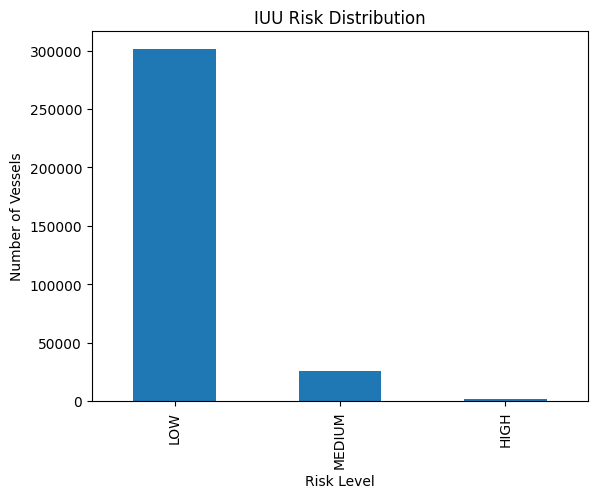

In [131]:
import matplotlib.pyplot as plt

df['risk_level'].value_counts().plot(kind='bar')

plt.title("IUU Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Vessels")
plt.show()

**Accuracy**

In [138]:
accuracy = (df['true_label'] == df['predicted_label']).mean()
print("Accuracy:", accuracy)

Accuracy: 0.8659737351362535
